# Replikasi Eksperimen Giudici et al. (2020)
## *Network Models to Improve Automated Cryptocurrency Portfolio Management*

Notebook ini membandingkan strategi-strategi portofolio berikut:
1. **Equally Weighted (EW)** — Portofolio naif (1/N)
2. **Classical Markowitz (CM)** — Optimasi Mean-Variance tradisional
3. **Glasso Markowitz (GM)** — Markowitz dengan regularisasi Graphical Lasso
4. **Network Markowitz (NW)** — Integrasi Random Matrix Theory (RMT) dan Minimum Spanning Tree (MST)
5. **Graph Diversification** — Diversifikasi berbasis Maximum Independent Set (MIS)
6. **Adaptive Graph-Gated Portfolio (AGGP)** — Model adaptif berbasis densitas graf

---
## Sel 1 — Persiapan Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.optimize import minimize
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.linalg import eigh
from sklearn.covariance import GraphicalLassoCV
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


---
## Sel 2 — Memuat Data

Memuat data return dan harga dari file Excel. Fokus utama adalah pada dataset return harian untuk 10 aset kripto utama dalam periode **14 September 2017 – 17 Oktober 2019**.

In [2]:
# Load data
excel_file = 'crypto_data_real.xlsx'
df_returns = pd.read_excel(excel_file, sheet_name='Returns', index_col=0)
df_prices  = pd.read_excel(excel_file, sheet_name='Prices',  index_col=0)

crypto_names = df_returns.columns.tolist()
n_assets     = len(crypto_names)

print(f"Data loaded: {df_returns.shape[0]} days, {n_assets} assets")
print(f"Period: {df_returns.index[0]} to {df_returns.index[-1]}")
df_returns.head()

Data loaded: 763 days, 10 assets
Period: 2017-09-15 00:00:00 to 2019-10-17 00:00:00


,BTC,ETH,XRP,USDT,BCH,LTC,BNB,EOS,XLM,TRX
Date,,,,,,,,,,
2017-09-15,0.142330,0.0,0.0,0.0,0.0,0.147883,0.0,0.0,0.0,0.0
2017-09-16,-0.003437,0.0,0.0,0.0,0.0,0.000947,0.0,0.0,0.0,0.0
2017-09-17,-0.011698,0.0,0.0,0.0,0.0,0.004794,0.0,0.0,0.0,0.0
2017-09-18,0.126296,0.0,0.0,0.0,0.0,0.135479,0.0,0.0,0.0,0.0
2017-09-19,-0.035104,0.0,0.0,0.0,0.0,-0.049661,0.0,0.0,0.0,0.0


---
## Sel 3 — Statistik Ringkasan (Table 1)

Tabel statistik deskriptif mencakup **Mean**, **Standar Deviasi**, **Kurtosis**, dan **Skewness** untuk setiap aset kripto.

In [3]:
# Create summary statistics table
summary_stats = pd.DataFrame({
    'Mean':     df_returns.mean(),
    'Std':      df_returns.std(),
    'Kurtosis': df_returns.kurt(),
    'Skewness': df_returns.skew()
})

print("TABLE 1 | Summary statistics.")
print(summary_stats.round(4))

TABLE 1 | Summary statistics.
        Mean     Std  Kurtosis  Skewness
BTC   0.0012  0.0434    3.0822    0.0523
ETH  -0.0008  0.0507    2.8209   -0.2916
XRP   0.0004  0.0654   18.9009    2.0588
USDT -0.0000  0.0057   21.7209    0.7437
BCH  -0.0014  0.0724    7.5671    0.6231
LTC   0.0004  0.0585    6.6357    1.0988
BNB   0.0029  0.0621   10.2612    1.0694
EOS   0.0012  0.0709    4.7582    0.5781
XLM   0.0006  0.0657    7.0332    0.9799
TRX   0.0025  0.0879   22.1856    2.6905


---
## Sel 4 — Visualisasi Harga Ternormalisasi (Figure 1 & 2)

Mereplikasi *Normalized cryptocurrency price series* dengan mengatur harga awal setiap aset menjadi **100** pada tanggal **7 Januari 2018**.

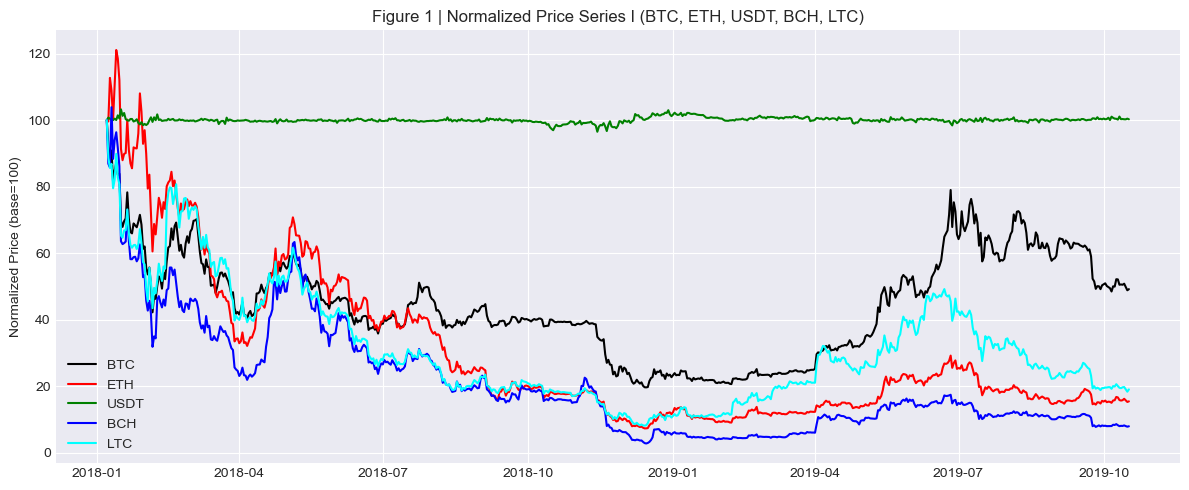

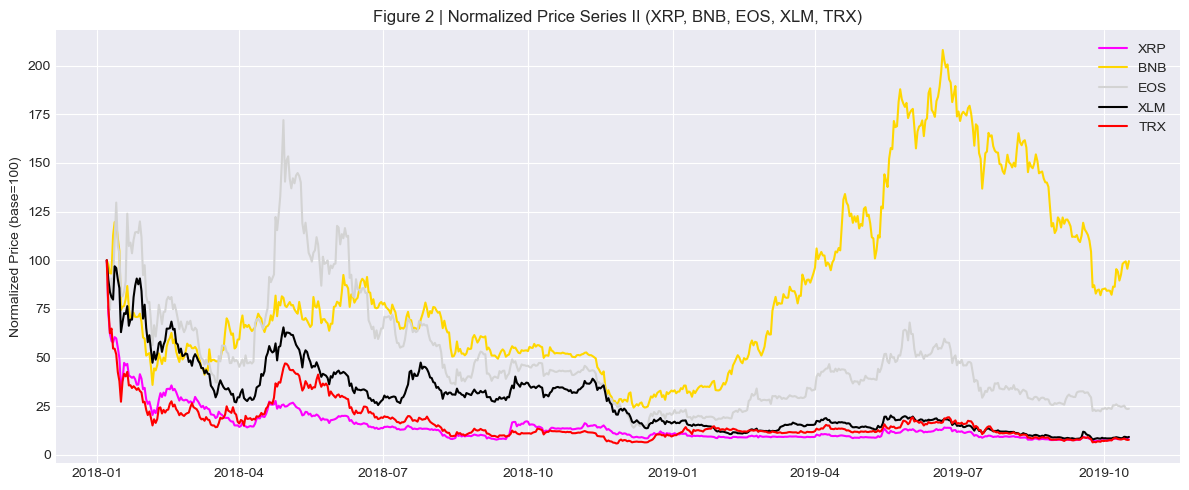

In [4]:
# --- Figure 1: BTC, ETH, USDT, BCH, LTC ---
assets_1  = ['BTC', 'ETH', 'USDT', 'BCH', 'LTC']
df_norm_1 = (df_prices.loc['2018-01-07':, assets_1] / df_prices.loc['2018-01-07', assets_1]) * 100
colors_1  = ['black', 'red', 'green', 'blue', 'cyan']

plt.figure(figsize=(12, 5))
for i, col in enumerate(df_norm_1.columns):
    plt.plot(df_norm_1.index, df_norm_1[col], label=col, color=colors_1[i])
plt.title('Figure 1 | Normalized Price Series I (BTC, ETH, USDT, BCH, LTC)')
plt.ylabel('Normalized Price (base=100)')
plt.legend()
plt.tight_layout()
plt.show()

# --- Figure 2: XRP, BNB, EOS, XLM, TRX ---
assets_2  = ['XRP', 'BNB', 'EOS', 'XLM', 'TRX']
df_norm_2 = (df_prices.loc['2018-01-07':, assets_2] / df_prices.loc['2018-01-07', assets_2]) * 100
colors_2  = ['magenta', 'gold', 'lightgrey', 'black', 'red']

plt.figure(figsize=(12, 5))
for i, col in enumerate(df_norm_2.columns):
    plt.plot(df_norm_2.index, df_norm_2[col], label=col, color=colors_2[i])
plt.title('Figure 2 | Normalized Price Series II (XRP, BNB, EOS, XLM, TRX)')
plt.ylabel('Normalized Price (base=100)')
plt.legend()
plt.tight_layout()
plt.show()

---
## Sel 5 — Visualisasi Minimum Spanning Tree (Figure 3 & 4)

Mereplikasi Figure 3 dari paper acuan yang menunjukkan struktur jaringan aset kripto:
- **Figure 3**: Periode gelembung spekulatif (Sep 2017 – Jan 2018)
- **Figure 4**: Periode stabil (Jun 2019 – Okt 2019)

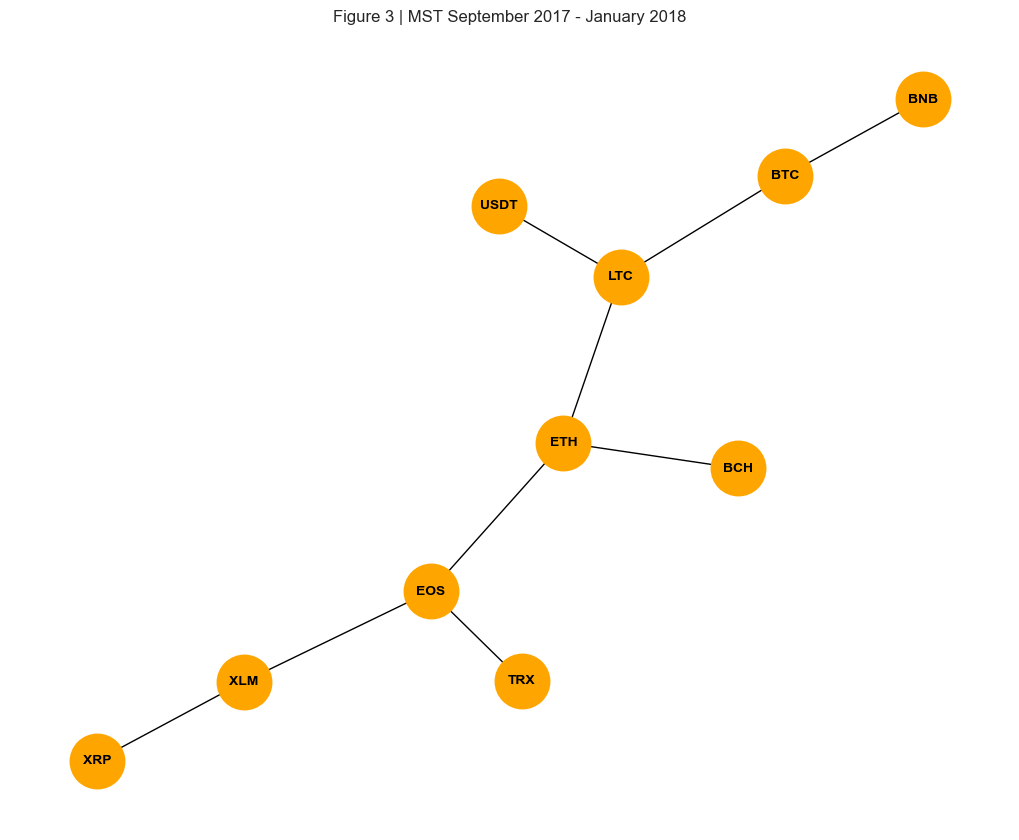

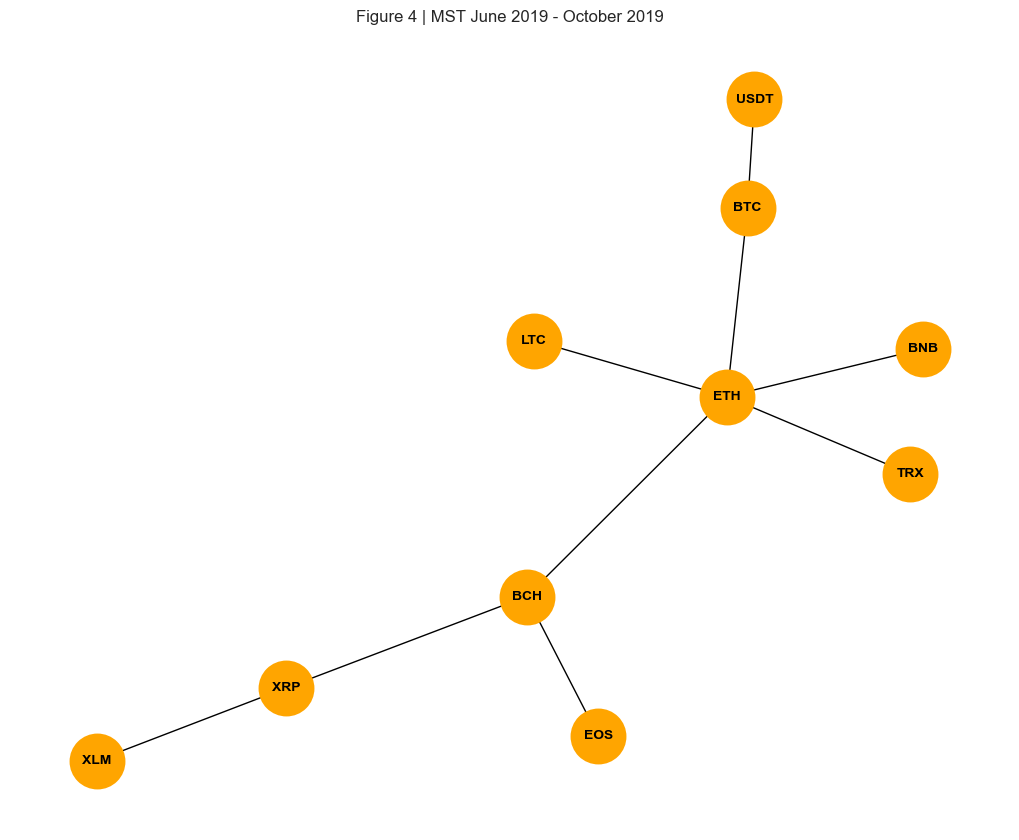

In [5]:
# --- Figure 3 | MST September 2017 - January 2018 ---
df_bubble   = df_returns.loc['2017-09-14':'2018-01-31']
corr_bubble = df_bubble.corr()
dist_bubble = np.sqrt(2 * (1 - corr_bubble))

G           = nx.from_pandas_adjacency(dist_bubble)
mst_bubble  = nx.minimum_spanning_tree(G, weight='weight')

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(mst_bubble, seed=42)
nx.draw(mst_bubble, pos, with_labels=True, node_color='orange',
        node_size=1500, edge_color='black', linewidths=1.5,
        font_size=10, font_weight='bold')
plt.title('Figure 3 | MST September 2017 - January 2018', fontsize=12)
plt.show()

# --- Figure 4 | MST June 2019 - October 2019 ---
df_stable   = df_returns.loc['2019-06-01':'2019-10-17']
corr_stable = df_stable.corr()
dist_stable = np.sqrt(2 * (1 - corr_stable))

G2          = nx.from_pandas_adjacency(dist_stable)
mst_stable  = nx.minimum_spanning_tree(G2, weight='weight')

plt.figure(figsize=(10, 8))
pos2 = nx.spring_layout(mst_stable, seed=42)
nx.draw(mst_stable, pos2, with_labels=True, node_color='orange',
        node_size=1500, edge_color='black', linewidths=1.5,
        font_size=10, font_weight='bold')
plt.title('Figure 4 | MST June 2019 - October 2019', fontsize=12)
plt.show()

---
## Sel 6 — Fungsi Pembantu (Helper Functions)

Implementasi:
- **RMT Filter** — Penyaringan noise pada matriks korelasi via Random Matrix Theory
- **MST Distance** — Konstruksi matriks jarak dari matriks korelasi
- **Eigenvector Centrality** — Pengukuran sentralitas node dalam jaringan
- **VaR, Rachev Ratio, Max Drawdown** — Metrik risiko portofolio
- **Graph Diversification** — Seleksi aset via Maximum Independent Set (MIS)

In [6]:
def apply_rmt_filter(returns_data):
    """Filter noise dari matriks korelasi menggunakan Random Matrix Theory (Marcenko-Pastur)."""
    if isinstance(returns_data, pd.DataFrame):
        data = returns_data.values
    else:
        data = returns_data
    T, N = data.shape
    Q    = T / N
    C    = np.corrcoef(data.T)

    eigenvalues, eigenvectors = eigh(C)
    eigenvalues  = eigenvalues[::-1]
    eigenvectors = eigenvectors[:, ::-1]

    lambda_plus      = 1 + (1/Q) + 2 * np.sqrt(1/Q)   # Marcenko-Pastur upper bound
    significant_mask = eigenvalues > lambda_plus
    Lambda_filtered  = np.diag(np.where(significant_mask, eigenvalues, 0))
    C_filtered       = eigenvectors @ Lambda_filtered @ eigenvectors.T
    return C_filtered


def build_mst(correlation_matrix):
    """Hitung matriks jarak dari matriks korelasi."""
    distance_matrix = np.sqrt(2 - 2 * correlation_matrix)
    np.fill_diagonal(distance_matrix, 0)
    return distance_matrix


def compute_eigenvector_centrality(distance_matrix):
    """Hitung sentralitas eigenvector dari matriks jarak."""
    adjacency = 1 / (distance_matrix + 1e-8)
    np.fill_diagonal(adjacency, 0)
    eigenvalues, eigenvectors = eigh(adjacency)
    principal_eigenvector     = np.abs(eigenvectors[:, -1])
    centrality                = principal_eigenvector / principal_eigenvector.sum()
    return centrality


def calculate_var(returns, confidence=0.95):
    """Value at Risk pada tingkat kepercayaan tertentu."""
    return np.percentile(returns, (1 - confidence) * 100)


def calculate_rachev_ratio(returns, alpha=0.10):
    """Rachev Ratio = CVaR_upper(alpha) / CVaR_lower(alpha)."""
    threshold_upper = np.percentile(returns, (1 - alpha) * 100)
    threshold_lower = np.percentile(returns, alpha * 100)
    cvar_upper      = returns[returns >= threshold_upper].mean()
    cvar_lower      = abs(returns[returns <= threshold_lower].mean())
    return cvar_upper / cvar_lower if cvar_lower > 0 else 0


def calculate_max_drawdown(cumulative_returns):
    """Maximum drawdown dari seri return kumulatif."""
    running_max = np.maximum.accumulate(cumulative_returns)
    drawdown    = (cumulative_returns - running_max) / running_max
    return drawdown.min()


def get_assets_graph_diversify(returns_window, corr_threshold=0.4):
    """Seleksi aset via Maximum Independent Set (MIS) pada graf korelasi."""
    corr_mat = returns_window.corr()
    G        = nx.Graph()
    assets   = list(returns_window.mean().sort_values(ascending=False).index)
    G.add_nodes_from(assets)
    for i, a1 in enumerate(assets):
        for a2 in assets[i+1:]:
            if abs(corr_mat.loc[a1, a2]) > corr_threshold:
                G.add_edge(a1, a2)
    return list(nx.approximation.maximum_independent_set(G))


def get_assets_graph_diversify_rmt(returns_window, corr_threshold=0.4):
    """Seleksi aset MIS dengan korelasi yang telah difilter RMT."""
    assets = returns_window.columns.tolist()
    corr_f = apply_rmt_filter(returns_window)
    G      = nx.Graph()
    G.add_nodes_from(assets)
    for i, a1 in enumerate(assets):
        for j, a2 in enumerate(assets):
            if i < j and abs(corr_f[i, j]) > corr_threshold:
                G.add_edge(a1, a2)
    return list(nx.approximation.maximum_independent_set(G))


print("Helper functions defined successfully!")

Helper functions defined successfully!


---
## Sel New — Analisis Dinamika MST (Figure 5)

Analisis *rolling window* untuk menghitung **max link distance** dan **koefisien residuality** dari MST sepanjang waktu.

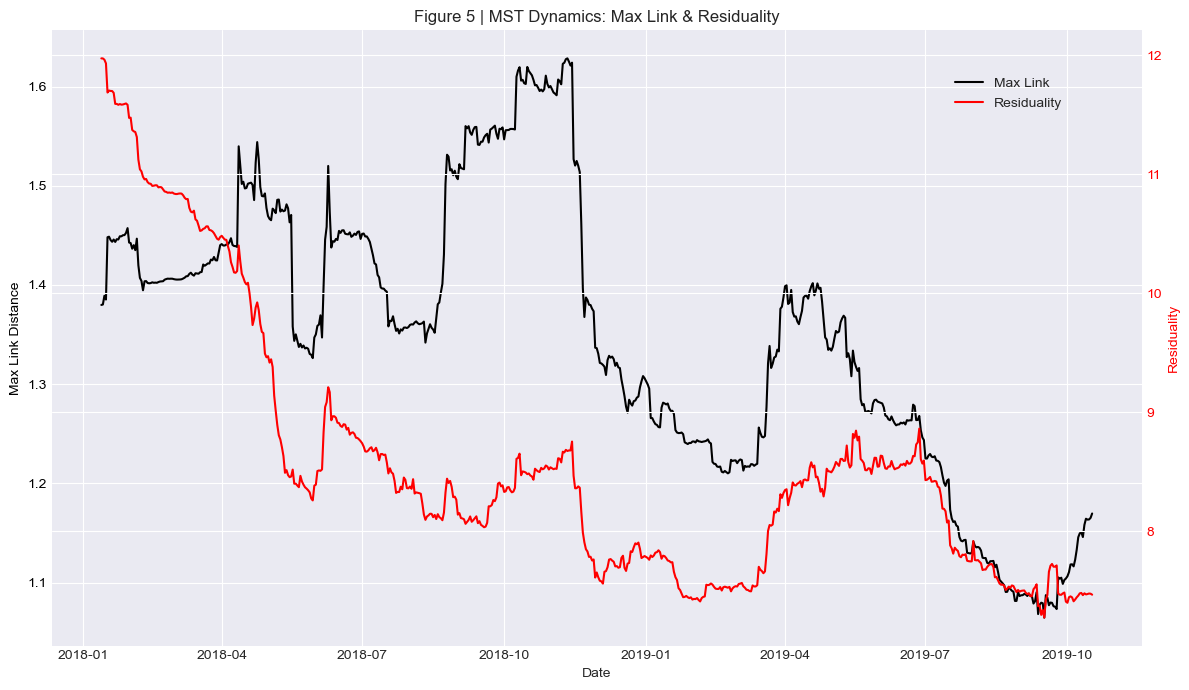

In [7]:
def calculate_rolling_mst_metrics(returns_df, window=120):
    """Hitung dinamika MST dengan rolling window."""
    dates         = returns_df.index[window:]
    max_links     = []
    residualities = []

    for i in range(window, len(returns_df)):
        window_data   = returns_df.iloc[i - window:i]
        corr_f        = apply_rmt_filter(window_data)
        mst_weights   = build_mst(corr_f)
        max_links.append(np.max(mst_weights))
        residualities.append(np.sum(mst_weights) / (returns_df.shape[1] - 1))

    return pd.DataFrame(
        {'Max Link': max_links, 'Residuality': residualities},
        index=dates
    )

mst_dyn = calculate_rolling_mst_metrics(df_returns)

# Visualisasi dual-axis
fig, ax1 = plt.subplots(figsize=(12, 7))
ax1.plot(mst_dyn.index, mst_dyn['Max Link'], color='black', label='Max Link')
ax1.set_xlabel('Date')
ax1.set_ylabel('Max Link Distance', color='black')
ax1.tick_params(axis='y', labelcolor='black')

ax2 = ax1.twinx()
ax2.plot(mst_dyn.index, mst_dyn['Residuality'], color='red', label='Residuality')
ax2.set_ylabel('Residuality', color='red')
ax2.tick_params(axis='y', labelcolor='red')

fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))
plt.title('Figure 5 | MST Dynamics: Max Link & Residuality')
plt.tight_layout()
plt.show()

---
## Sel 7 — Implementasi Strategi Portofolio

Setiap strategi diimplementasikan sebagai kelas yang mewarisi `PortfolioStrategy`.

| Kelas | Deskripsi |
|---|---|
| `EquallyWeighted` | Portofolio naif 1/N |
| `ClassicalMarkowitz` | Minimasi varians Mean-Variance tradisional |
| `GlassoMarkowitz` | Markowitz + estimasi Graphical Lasso |
| `NetworkMarkowitz` | RMT + MST + penalti sentralitas eigenvector (parameter γ) |
| `GraphDiversification` | Maximum Independent Set pada graf korelasi |
| `RMTGraphDiversification` | MIS dengan korelasi ter-filter RMT |
| `AdaptiveGraphPortfolio` | AGGP: gamma adaptif berbasis densitas graf |

In [8]:
class PortfolioStrategy:
    def __init__(self, name):
        self.name            = name
        self.weights_history = []
        self.returns_history = []

    def get_weights(self, returns_data):
        raise NotImplementedError


class EquallyWeighted(PortfolioStrategy):
    def get_weights(self, returns_data):
        n = returns_data.shape[1]
        return np.ones(n) / n


class ClassicalMarkowitz(PortfolioStrategy):
    """Optimasi Mean-Variance tradisional (minimasi varians portofolio)."""
    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        mu       = returns_data.mean().values
        S        = returns_data.cov().values

        objective   = lambda w: w @ S @ w
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(n_assets) / n_assets,
                       method='SLSQP', bounds=[(0, 1)] * n_assets,
                       constraints=constraints)
        return res.x if res.success else np.ones(n_assets) / n_assets


class GlassoMarkowitz(PortfolioStrategy):
    """Markowitz dengan matriks presisi yang diestimasi via Graphical Lasso."""
    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        mu       = returns_data.mean().values
        try:
            glasso = GraphicalLassoCV()
            glasso.fit(returns_data.values)
            S = glasso.covariance_
        except Exception:
            S = returns_data.cov().values
        objective   = lambda w: w @ S @ w
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(n_assets) / n_assets,
                       method='SLSQP', bounds=[(0, 1)] * n_assets,
                       constraints=constraints)
        return res.x if res.success else np.ones(n_assets) / n_assets


class NetworkMarkowitz(PortfolioStrategy):
    """Network Markowitz: RMT + MST + penalti sentralitas eigenvector (gamma)."""
    def __init__(self, name='Network Markowitz', gamma=0):
        super().__init__(name)
        self.gamma = gamma

    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        mu       = returns_data.mean().values
        sig      = returns_data.std().values
        Cf       = apply_rmt_filter(returns_data)
        dist     = build_mst(Cf)
        cent     = compute_eigenvector_centrality(dist)
        Sf       = np.outer(sig, sig) * Cf

        objective   = lambda w: w @ Sf @ w + self.gamma * np.sum(cent * w)
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(n_assets) / n_assets,
                       method='SLSQP', bounds=[(0, 1)] * n_assets,
                       constraints=constraints)
        return res.x if res.success else np.ones(n_assets) / n_assets


class GraphDiversification(PortfolioStrategy):
    """Diversifikasi berbasis graf menggunakan Maximum Independent Set."""
    def __init__(self, name='Graph Diversification', corr_threshold=0.4):
        super().__init__(name)
        self.corr_threshold = corr_threshold

    def get_weights(self, r):
        n      = r.shape[1]
        assets = r.columns.tolist()
        sel    = get_assets_graph_diversify(r, self.corr_threshold)
        w      = np.zeros(n)
        if sel:
            for a in sel:
                w[assets.index(a)] = 1.0 / len(sel)
        else:
            w = np.ones(n) / n
        return w


class RMTGraphDiversification(PortfolioStrategy):
    """Graph Diversification dengan seleksi MIS berbasis korelasi ter-filter RMT."""
    def __init__(self, name='RMT Graph Diversification', corr_threshold=0.4):
        super().__init__(name)
        self.corr_threshold = corr_threshold

    def get_weights(self, r):
        n      = r.shape[1]
        assets = r.columns.tolist()
        sel    = get_assets_graph_diversify_rmt(r, self.corr_threshold)
        w      = np.zeros(n)
        if sel:
            for a in sel:
                w[assets.index(a)] = 1.0 / len(sel)
        else:
            w = np.ones(n) / n
        return w


class AdaptiveGraphPortfolio(PortfolioStrategy):
    """Adaptive Graph-Gated Portfolio (AGGP): gamma adaptif berbasis densitas graf."""
    def __init__(self, name='AGGP (Optimized)', sensitivity=2.0):
        super().__init__(name)
        self.sensitivity = sensitivity

    def get_weights(self, returns_data):
        n  = returns_data.shape[1]
        mu = returns_data.mean().values
        try:
            glasso = GraphicalLassoCV(cv=5)
            glasso.fit(returns_data.values)
            Sf = glasso.covariance_
            Cf = glasso.precision_   # Note: gunakan korelasi jika diperlukan
            Cf = apply_rmt_filter(returns_data)  # fallback ke RMT
        except:
            Cf = apply_rmt_filter(returns_data)
            Sf = np.outer(returns_data.std(), returns_data.std()) * Cf

        adj      = (np.abs(Cf) > 0.5).astype(int)
        G        = nx.from_numpy_array(adj)
        density  = nx.density(G)
        gamma_t  = np.clip(density * self.sensitivity, 0.1, 0.9)

        dist  = build_mst(Cf)
        cent  = compute_eigenvector_centrality(dist)
        w_net = 1.0 / (cent + 1e-6)
        w_net /= w_net.sum()

        res_mko = minimize(
            lambda w: w @ Sf @ w,
            np.ones(n) / n,
            method='SLSQP',
            bounds=[(0, 1)] * n,
            constraints=({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
        )
        return (1 - gamma_t) * res_mko.x + gamma_t * w_net


print("Portfolio strategy classes defined successfully!")

Portfolio strategy classes defined successfully!


---
## Sel 8 — Framework Backtesting

Simulasi menggunakan **rolling window** dengan:
- `window_size = 120` hari pelatihan
- `rebalance_freq = 7` hari (rebalancing mingguan)
- `transaction_cost = 0.001` (10 basis points)

In [9]:
def backtest_strategy(strategy, df_returns, window_size=120, rebalance_freq=7, transaction_cost=0.001):
    """Simulasi backtest rolling-window untuk satu strategi portofolio."""
    portfolio_returns = []
    dates             = []

    for i in range(window_size, len(df_returns), rebalance_freq):
        train     = df_returns.iloc[i - window_size:i]
        w         = strategy.get_weights(train)
        test_end  = min(i + rebalance_freq, len(df_returns))
        test_data = df_returns.iloc[i:test_end]

        for j in range(len(test_data)):
            daily_ret = np.dot(w, test_data.iloc[j].values)
            if j == 0 and len(portfolio_returns) > 0:
                daily_ret -= transaction_cost
            portfolio_returns.append(daily_ret)
            dates.append(test_data.index[j])

    res_df = pd.DataFrame({'date': dates, 'return': portfolio_returns})
    res_df['cumulative_return'] = (1 + res_df['return']).cumprod()

    return {
        'strategy':           strategy.name,
        'returns':            np.array(portfolio_returns),
        'cumulative_returns': res_df['cumulative_return'].values,
        'results_df':         res_df
    }

print("Backtest framework defined!")

Backtest framework defined!


---
## Sel 9 — Eksekusi Backtesting

Menjalankan simulasi untuk semua varian strategi, termasuk benchmark dan model dengan berbagai nilai penalti **γ**.

In [10]:
# --- Inisialisasi strategi ---
gamma_values = [0.005, 0.025, 0.05, 0.15, 0.7, 1.0]

strategies = [
    EquallyWeighted("EW"),
    ClassicalMarkowitz("CM"),
    GlassoMarkowitz("GM"),
    NetworkMarkowitz("NW (gamma=0)", gamma=0),
] + [
    NetworkMarkowitz(f"NW (gamma={g})", gamma=g) for g in gamma_values
] + [
    GraphDiversification('Graph Divers. (theta=0.4)', corr_threshold=0.4),
    GraphDiversification('Graph Divers. (theta=0.5)', corr_threshold=0.5),
    RMTGraphDiversification('RMT GD (theta=0.4)',     corr_threshold=0.4),
    AdaptiveGraphPortfolio("AGGP (Optimized)",         sensitivity=2.0)
]

# --- Eksekusi backtest ---
results = {}
for strat in strategies:
    print(f"Running: {strat.name} ...", end=' ')
    results[strat.name] = backtest_strategy(strat, df_returns)
    print("Done")

print("\nAll strategies backtested!")

Running: EW ... Done
Running: CM ... Done
Running: GM ... Done
Running: NW (gamma=0) ... Done
Running: NW (gamma=0.005) ... Done
Running: NW (gamma=0.025) ... Done
Running: NW (gamma=0.05) ... Done
Running: NW (gamma=0.15) ... Done
Running: NW (gamma=0.7) ... Done
Running: NW (gamma=1.0) ... Done
Running: Graph Divers. (theta=0.4) ... Done
Running: Graph Divers. (theta=0.5) ... Done
Running: RMT GD (theta=0.4) ... Done
Running: AGGP (Optimized) ... Done

All strategies backtested!


---
## Sel 10 — Analisis Performa Periodik (Table 2)

Tabel perbandingan **Cumulative Profit/Loss** yang disampel setiap 4 bulan (Januari, Mei, September), mereplikasi format Tabel 2 pada paper acuan.

In [11]:
target_dates = [
    '2018-01-31', '2018-05-31', '2018-09-30',
    '2019-01-31', '2019-05-31', '2019-09-30'
]

table2_rows = []
for strat_name, res in results.items():
    df_res = res['results_df'].set_index('date')
    row    = {'Strategy': strat_name}
    for td in target_dates:
        idx     = df_res.index.searchsorted(pd.Timestamp(td))
        idx     = min(idx, len(df_res) - 1)
        cum_ret = (df_res['cumulative_return'].iloc[idx] - 1) * 100
        row[td] = round(cum_ret, 2)
    table2_rows.append(row)

table2 = pd.DataFrame(table2_rows).set_index('Strategy')
table2.columns = ['Jan-2018', 'May-2018', 'Sep-2018', 'Jan-2019', 'May-2019', 'Sep-2019']

print("TABLE 2 | Cumulative Profits and Losses (%)")
table2

TABLE 2 | Cumulative Profits and Losses (%)


,Jan-2018,May-2018,Sep-2018,Jan-2019,May-2019,Sep-2019
Strategy,,,,,,
EW,-35.53,-58.96,-77.02,-89.67,-77.88,-88.82
CM,-34.32,-57.88,-59.66,-68.22,-55.67,-62.16
GM,-33.86,-60.11,-61.90,-73.12,-62.49,-67.53
NW (gamma=0),-41.59,-62.30,-63.81,-71.79,-61.83,-68.05
NW (gamma=0.005),-41.62,-61.76,-64.22,-71.33,-62.41,-68.75
NW (gamma=0.025),-44.13,-64.87,-66.29,-66.72,-57.08,-66.33
NW (gamma=0.05),-44.80,-63.44,-64.60,-65.06,-55.14,-61.98
NW (gamma=0.15),-44.65,-56.79,-58.18,-58.72,-46.94,-54.22
NW (gamma=0.7),-40.13,-52.75,-54.21,-54.80,-41.90,-48.76


---
## Sel 11 — Visualisasi Performa Kumulatif (Figure 6)

Evolusi nilai portofolio dengan asumsi **investasi awal 100 USD** untuk periode **7 Januari 2018 – 17 Oktober 2019**.

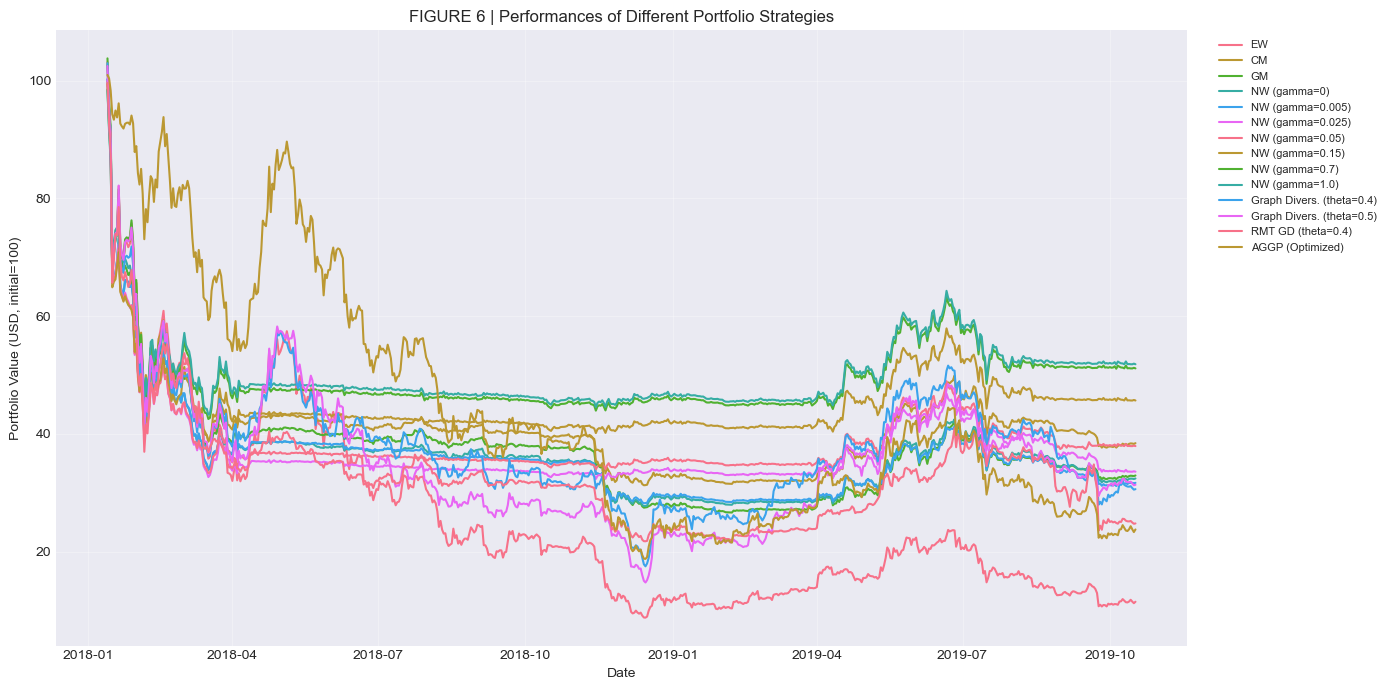

In [12]:
plt.figure(figsize=(14, 7))
for name, res in results.items():
    plt.plot(res['results_df']['date'],
             res['cumulative_returns'] * 100,
             label=name)

plt.title('FIGURE 6 | Performances of Different Portfolio Strategies')
plt.xlabel('Date')
plt.ylabel('Portfolio Value (USD, initial=100)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Sel 12 — Analisis Risiko Periodik (Table 3 — VaR 95%)

**Value at Risk** (VaR) dihitung pada jendela 4 bulan terakhir di setiap titik sampling.
Nilai disajikan dalam nilai absolut × faktor skala 100, sesuai paper acuan.

In [13]:
var_strategies = ['EW', 'CM', 'GM', 'NW (gamma=0)', 'AGGP (Optimized)']
table3_rows    = []

for strat_name in var_strategies:
    if strat_name not in results:
        continue
    res    = results[strat_name]
    df_res = res['results_df'].set_index('date')
    row    = {'Strategy': strat_name}

    for td in target_dates:
        idx_end   = df_res.index.searchsorted(pd.Timestamp(td))
        idx_start = max(0, idx_end - 120)  # ~4 bulan
        segment   = df_res['return'].iloc[idx_start:idx_end].values
        if len(segment) > 0:
            v = abs(calculate_var(segment, 0.95)) * 100
        else:
            v = np.nan
        row[td] = round(v, 4)
    table3_rows.append(row)

table3 = pd.DataFrame(table3_rows).set_index('Strategy')
table3.columns = ['Jan-2018', 'May-2018', 'Sep-2018', 'Jan-2019', 'May-2019', 'Sep-2019']

print("TABLE 3 | VaR 95% (4-month window, scaled x100)")
table3

TABLE 3 | VaR 95% (4-month window, scaled x100)


,Jan-2018,May-2018,Sep-2018,Jan-2019,May-2019,Sep-2019
Strategy,,,,,,
EW,14.3785,9.5511,6.5605,9.5853,3.6840,8.2936
CM,13.4893,5.8008,1.0019,1.7321,1.7011,3.8603
GM,14.1042,5.9287,1.1914,2.4632,1.8379,4.3053
NW (gamma=0),13.2949,5.6166,1.1648,1.8600,1.5141,4.0299
AGGP (Optimized),4.2914,6.8157,5.4662,8.3483,3.1793,7.2199


---
## Sel 13 — Analisis Risk-Adjusted Return (Table 4 — Sharpe Ratio)

**Sharpe Ratio** dihitung per jendela 4 bulan:
$$SR = \frac{\bar{r}}{\sigma_r}$$

In [14]:
sr_strategies = ['GM', 'EW', 'CM', 'NW (gamma=0)', 'NW (gamma=0.15)', 'AGGP (Optimized)']
table4_rows   = []

for strat_name in sr_strategies:
    if strat_name not in results:
        continue
    res    = results[strat_name]
    df_res = res['results_df'].set_index('date')
    row    = {'Strategy': strat_name}

    for td in target_dates:
        idx_end   = df_res.index.searchsorted(pd.Timestamp(td))
        idx_start = max(0, idx_end - 120)
        segment   = df_res['return'].iloc[idx_start:idx_end].values
        if len(segment) > 1:
            sr = np.mean(segment) / np.std(segment)
        else:
            sr = np.nan
        row[td] = round(sr, 4)
    table4_rows.append(row)

table4 = pd.DataFrame(table4_rows).set_index('Strategy')
table4.columns = ['Jan-2018', 'May-2018', 'Sep-2018', 'Jan-2019', 'May-2019', 'Sep-2019']

print("TABLE 4 | Sharpe Ratio (4-month window)")
table4

TABLE 4 | Sharpe Ratio (4-month window)


,Jan-2018,May-2018,Sep-2018,Jan-2019,May-2019,Sep-2019
Strategy,,,,,,
GM,-0.2703,-0.0942,-0.0603,-0.1855,0.1671,-0.0552
EW,-0.2788,-0.0427,-0.1002,-0.1213,0.1864,-0.1403
CM,-0.2885,-0.0880,-0.0644,-0.1492,0.1827,-0.0627
NW (gamma=0),-0.3885,-0.0946,-0.0596,-0.1531,0.1780,-0.0732
NW (gamma=0.15),-0.4456,-0.0400,-0.0636,-0.0136,0.1523,-0.0601
AGGP (Optimized),-0.3481,-0.0364,-0.1037,-0.1232,0.1858,-0.1413


---
## Sel 14 — Analisis Tail-Risk (Table 5 — Rachev Ratio)

**Rachev Ratio** (RR) mengukur asimetri distribusi return pada ekor distribusi:
$$RR = \frac{CVaR_{upper}(10\%)}{CVaR_{lower}(10\%)}$$

RR > 1 menunjukkan potensi upside lebih besar dari downside pada ekor distribusi.

In [15]:
rr_strategies = ['GM', 'EW', 'CM', 'NW (gamma=0)', 'NW (gamma=0.15)', 'AGGP (Optimized)']
table5_rows   = []

for strat_name in rr_strategies:
    if strat_name not in results:
        continue
    res    = results[strat_name]
    df_res = res['results_df'].set_index('date')
    row    = {'Strategy': strat_name}

    for td in target_dates:
        idx_end   = df_res.index.searchsorted(pd.Timestamp(td))
        idx_start = max(0, idx_end - 120)
        segment   = df_res['return'].iloc[idx_start:idx_end].values
        if len(segment) > 1:
            rr = calculate_rachev_ratio(segment, alpha=0.10)
        else:
            rr = np.nan
        row[td] = round(rr, 4)
    table5_rows.append(row)

table5 = pd.DataFrame(table5_rows).set_index('Strategy')
table5.columns = ['Jan-2018', 'May-2018', 'Sep-2018', 'Jan-2019', 'May-2019', 'Sep-2019']

print("TABLE 5 | Rachev Ratio (4-month window, alpha=10%)")
table5

TABLE 5 | Rachev Ratio (4-month window, alpha=10%)


,Jan-2018,May-2018,Sep-2018,Jan-2019,May-2019,Sep-2019
Strategy,,,,,,
GM,0.4126,0.7537,0.7754,0.5564,1.6893,0.7242
EW,0.3926,0.8889,0.8079,0.7245,1.7430,0.5213
CM,0.3969,0.7645,0.7788,0.6455,2.0115,0.7408
NW (gamma=0),0.2494,0.7633,0.7773,0.6388,2.1048,0.7696
NW (gamma=0.15),0.1822,1.0085,0.8412,1.0197,2.1687,0.8334
AGGP (Optimized),0.4523,0.9170,0.7907,0.7235,1.7581,0.5238
